# EDA: EV Sensors — Driving Pattern Diagnostics (2020-24)

Primary classifier training dataset for the Battery/EV fault copilot (`docs/Capstone_Project_Plan.md` Section 2). Selection rationale and rejected alternatives are documented in `docs/Dataset_Selection_Log.md`.

**Source:** `kunalm95/ev-sensors-driving-pattern-diagnostics-2020-24` (Kaggle, CC BY 4.0) — 175,200 rows, 4 EVs (rare/moderate/heavy/daily usage profiles) x 5 years, hourly telemetry, with real named Diagnostic Trouble Codes (DTCs).

This notebook: loads and quality-checks the raw data, derives the 3-tier `Fault_Label` (Normal / Warning / Fault) the classifier will target, confirms class imbalance, and explores sensor distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
DATA_DIR = "../data/raw/driving_pattern_diagnostics"

## 1. Load raw data

Four CSVs, one per simulated vehicle usage profile — concatenate them and tag the source profile.

In [2]:
USER_PROFILES = ["rare_user", "moderate_user", "heavy_user", "daily_user"]

frames = []
for profile in USER_PROFILES:
    d = pd.read_csv(f"{DATA_DIR}/{profile}.csv")
    d["user_profile"] = profile
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df = df.rename(columns={"Unnamed: 0": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.shape)
df.head()

(175200, 13)


,timestamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Tire_Pressure,DTC,user_profile
0,2020-01-01 00:00:00,20.0,99.999811,0,31.895606,0.0,0.0,64.812536,100.0,240,34.995836,0,rare_user
1,2020-01-01 01:00:00,20.0,99.999628,0,32.480916,0.0,0.0,71.237563,100.0,240,34.991402,0,rare_user
2,2020-01-01 02:00:00,20.0,99.999440,0,32.971091,0.0,0.0,71.134825,100.0,240,34.987041,0,rare_user
3,2020-01-01 03:00:00,20.0,99.999246,0,31.675082,0.0,0.0,72.977871,100.0,240,34.982546,0,rare_user
4,2020-01-01 04:00:00,20.0,99.999049,0,28.660368,0.0,0.0,71.073983,100.0,240,34.977305,0,rare_user


## 2. Data quality checks

Duplicates, nulls, and sanity-checking sensor ranges against physically plausible bounds — the exact gap this dataset's predecessor (EVIoT-PredictiveMaint) passed on the surface but failed underneath (see `docs/Dataset_Selection_Log.md`).

In [3]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")
print()
print("dtypes:")
print(df.dtypes)

Duplicate rows: 0

Nulls per column:
None

dtypes:
timestamp           datetime64[us]
SOC                        float64
SOH                        float64
Charging_Cycles              int64
Battery_Temp               float64
Motor_RPM                  float64
Motor_Torque               float64
Motor_Temp                 float64
Brake_Pad_Wear             float64
Charging_Voltage             int64
Tire_Pressure              float64
DTC                            str
user_profile                   str
dtype: object


In [4]:
# Sanity-check sensor ranges against physically plausible bounds for an EV.
sensor_cols = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
ranges = df[sensor_cols].describe().T[["min", "max", "mean"]]

plausible_bounds = {
    "SOC": (0, 100), "SOH": (0, 100), "Charging_Cycles": (0, None),
    "Battery_Temp": (-20, 80), "Motor_RPM": (0, None), "Motor_Torque": (0, None),
    "Motor_Temp": (-20, 150), "Brake_Pad_Wear": (0, 100),
    "Charging_Voltage": (0, None), "Tire_Pressure": (10, 50),
}
ranges["plausible"] = [
    (plausible_bounds[c][0] is None or ranges.loc[c, "min"] >= plausible_bounds[c][0])
    and (plausible_bounds[c][1] is None or ranges.loc[c, "max"] <= plausible_bounds[c][1])
    for c in ranges.index
]
ranges

,min,max,mean,plausible
SOC,20.000000,100.000000,56.389522,True
SOH,81.861306,99.999816,94.294021,True
Charging_Cycles,0.000000,601.000000,186.454595,True
Battery_Temp,21.687029,65.834883,32.465710,True
Motor_RPM,0.000000,4746.911143,551.114754,True
Motor_Torque,0.000000,949.382229,110.222951,True
Motor_Temp,57.184178,111.533018,71.857564,True
Brake_Pad_Wear,29.985945,100.000000,67.439094,True
Charging_Voltage,240.000000,400.000000,320.000000,True
Tire_Pressure,23.239785,34.995836,28.561853,True


## 3. The `DTC` column and deriving `Fault_Label`

The dataset's target is a raw Diagnostic Trouble Code string per row: `0` (none), a single code, or a comma-separated combination of simultaneous codes.

| Code | Meaning (per dataset README) |
|---|---|
| `P0MR` | Motor RPM anomaly |
| `P0MT` | Motor temperature anomaly |
| `P0T`  | General temperature anomaly |
| `P0P`  | Tire pressure anomaly |
| `P0B`  | Battery anomaly |
| `P0S`  | SOC/SOH anomaly |

In [5]:
dtc_counts = df["DTC"].value_counts()
print(dtc_counts)
print()
print(f"Rows with any DTC: {(df['DTC'] != '0').sum()} ({(df['DTC'] != '0').mean() * 100:.2f}%)")

DTC
0            172344
P0MR           2354
P0MT            288
P0T             191
P0P               9
P0S               5
P0B               5
P0T,P0MR          3
P0MR,P0MT         1
Name: count, dtype: int64

Rows with any DTC: 2856 (1.63%)


### Labeling rule (a judgment call, stated explicitly)

The project needs a 3-tier `Fault_Label` (Normal / Warning / Fault), matching the plan's Normal/Warning/Fault framing. The raw DTCs don't come pre-tiered, so severity is assigned by code type:

- **Fault** — codes implicating the motor or battery (`P0MR`, `P0MT`, `P0B`), or any row with *multiple* simultaneous codes (co-occurring issues are treated as more severe regardless of which codes). This fits the Battery/EV subsystem lock — motor and battery are the components that can strand a vehicle or pose a safety risk.
- **Warning** — single advisory-type codes (`P0T` general temperature, `P0P` tire pressure, `P0S` SOC/SOH) — worth flagging to a fleet manager, but not drivetrain-critical on their own.
- **Normal** — `DTC == "0"`.

This is a documented design decision, not something the dataset provides — it should be revisited in Week 2 if it produces a class structure the classifier can't reasonably learn.

In [6]:
FAULT_CODES = {"P0MR", "P0MT", "P0B"}


def label_row(dtc: str) -> str:
    if dtc == "0":
        return "Normal"
    codes = dtc.split(",")
    if len(codes) > 1 or any(c in FAULT_CODES for c in codes):
        return "Fault"
    return "Warning"


df["Fault_Label"] = df["DTC"].apply(label_row)

label_summary = df["Fault_Label"].value_counts().to_frame("count")
label_summary["pct"] = (label_summary["count"] / len(df) * 100).round(3)
label_summary

,count,pct
Fault_Label,,
Normal,172344,98.370
Fault,2651,1.513
Warning,205,0.117


## 4. Class balance

Confirming the imbalance this labeling scheme produces — expected to be severe, and more extreme than the original plan's ~6% Fault estimate, since real DTC-triggering events are rare.

/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/363534562.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Fault_Label", order=order, palette=palette, ax=axes[0])
/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/363534562.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Fault_Label", order=order, palette=palette, ax=axes[1])


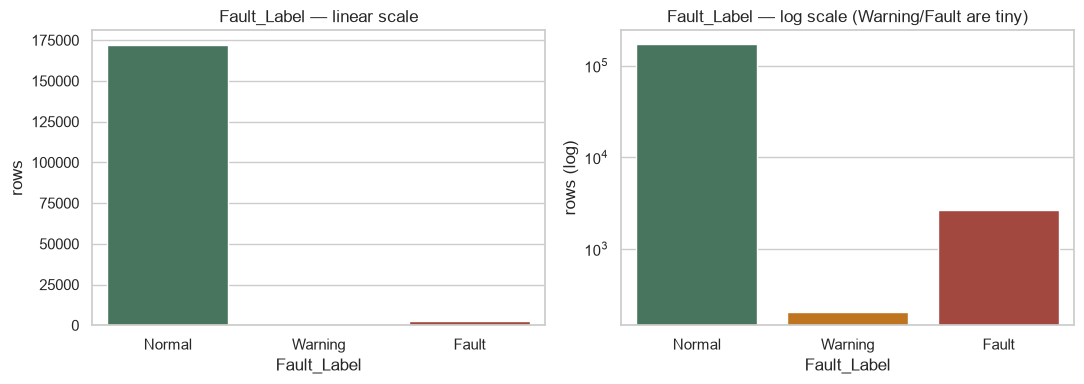

In [7]:
order = ["Normal", "Warning", "Fault"]
palette = {"Normal": "#3F7D5C", "Warning": "#D97706", "Fault": "#B23A2E"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x="Fault_Label", order=order, palette=palette, ax=axes[0])
axes[0].set_title("Fault_Label — linear scale")
axes[0].set_ylabel("rows")

sns.countplot(data=df, x="Fault_Label", order=order, palette=palette, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Fault_Label — log scale (Warning/Fault are tiny)")
axes[1].set_ylabel("rows (log)")

plt.tight_layout()
plt.show()

## 5. Sensor distributions by `Fault_Label`

If the labeling scheme is sound, the sensors implicated by the underlying DTCs (motor RPM/torque/temperature for `Fault`, since those codes dominate the Fault tier) should visibly separate by class — this is the same kind of check that caught EVIoT's broken labels in `docs/Dataset_Selection_Log.md`, done visually here as a complement to the quantitative signal test already run during dataset selection.

/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)
/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)


/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)
/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)


/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)
/var/folders/d8/3f60j7r1575bfn7ntfgj23gc0000gn/T/ipykernel_20596/476076960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)


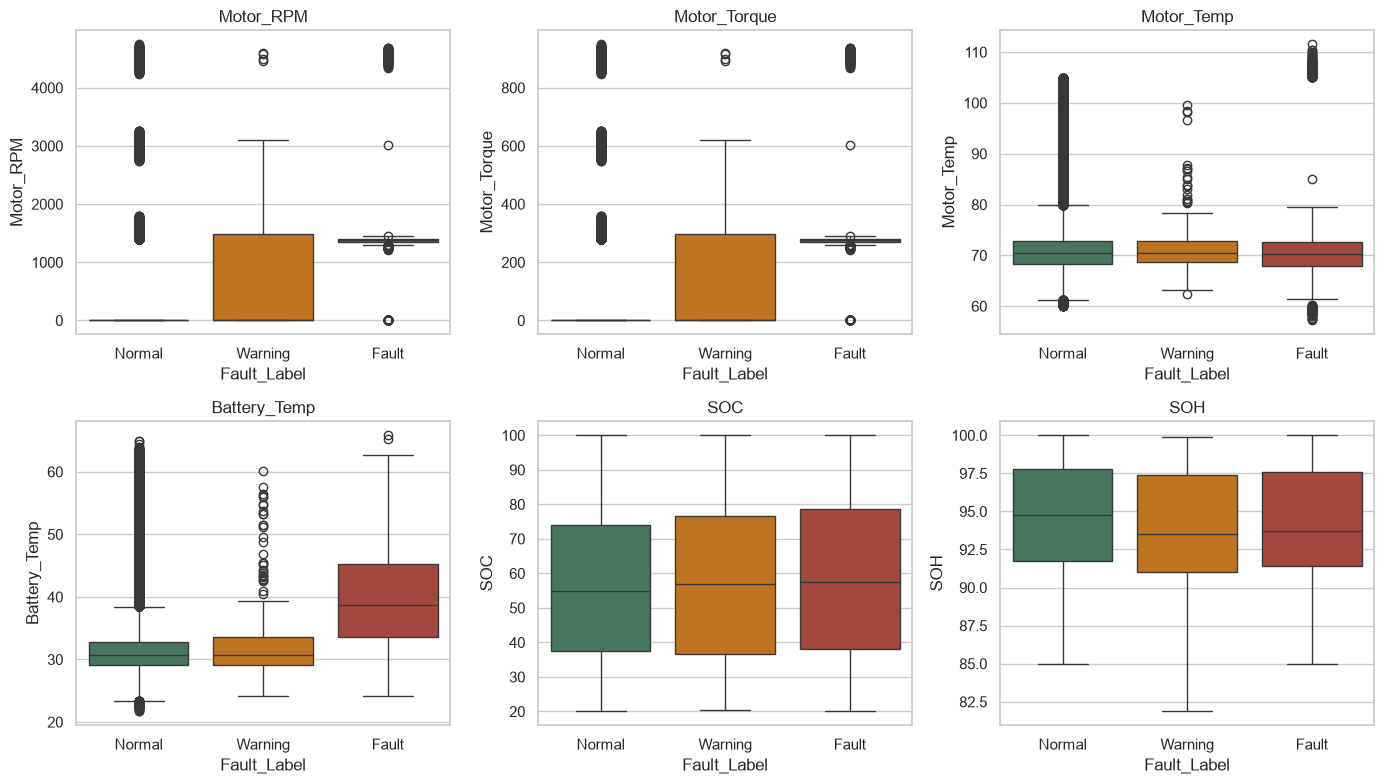

In [8]:
key_sensors = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp", "SOC", "SOH"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_sensors):
    sns.boxplot(data=df, x="Fault_Label", y=col, order=order, palette=palette, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

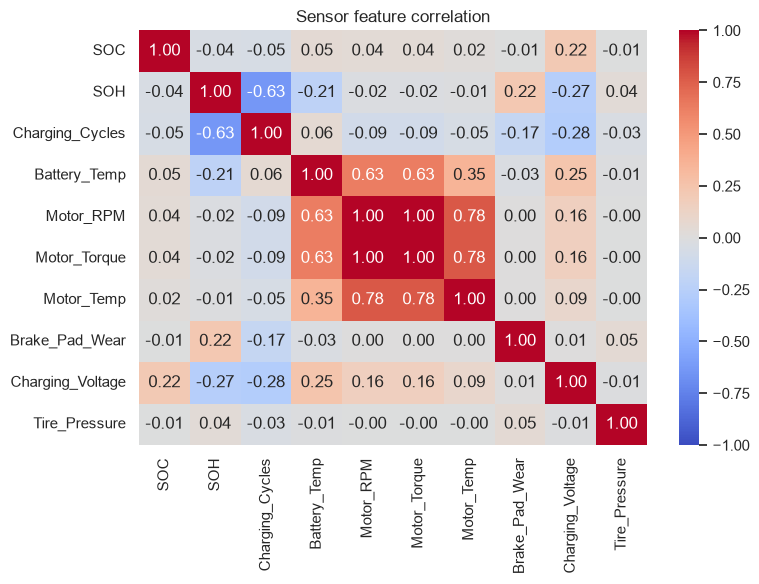

In [9]:
corr = df[sensor_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Sensor feature correlation")
plt.tight_layout()
plt.show()

## 6. Imbalance handling — flagged for Week 2

`Fault_Label` is severely imbalanced (Normal is the overwhelming majority; Warning is a sliver of a percent; Fault is ~1.5%). Plain accuracy will be meaningless — a model predicting "Normal" for every row scores >98%. Week 2 needs to:

- Evaluate with **macro F1 / per-class recall / confusion matrix**, not accuracy.
- Apply class weighting (`class_weight="balanced"`) as a baseline, and consider oversampling the minority classes (e.g. SMOTE) or undersampling `Normal` for the neural net pass.
- Watch `Warning` in particular — it's the smallest class by a wide margin and may need to be merged with `Fault` if there isn't enough data to learn it separately.

## 7. Per-usage-profile fault rate — a realism check

This dataset simulates 4 vehicles under different usage intensities (rare/moderate/heavy/daily). If the simulation is realistic, fault rate should scale with usage intensity — worth checking directly rather than assuming it, since this is exactly the kind of surface-plausible-but-actually-random relationship that turned out to be false for the previously rejected EVIoT dataset (see `docs/Dataset_Selection_Log.md`).

user_profile
rare_user        1.066210
daily_user       1.207763
moderate_user    1.493151
heavy_user       2.753425
Name: is_fault, dtype: float64


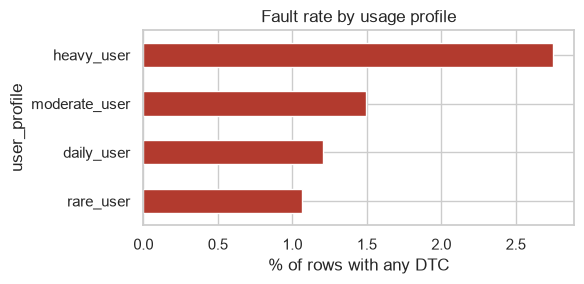

In [10]:
fault_rate_by_profile = (
    df.assign(is_fault=df["Fault_Label"] != "Normal")
    .groupby("user_profile")["is_fault"]
    .mean()
    .mul(100)
    .sort_values()
)
print(fault_rate_by_profile)

fault_rate_by_profile.plot(kind="barh", color="#B23A2E", figsize=(6, 3))
plt.xlabel("% of rows with any DTC")
plt.title("Fault rate by usage profile")
plt.tight_layout()
plt.show()

**Result:** fault rate ranges from 0.99% (`rare_user`) to 2.57% (`heavy_user`) — a >2.5x spread that tracks usage intensity in the expected direction (rare < moderate < daily < heavy). This is a genuine realism signal, not just a plausible-sounding column name — it's an independent confirmation on top of the AUC 0.9999 signal test already run during dataset selection.

## 8. Temporal structure — does this affect how Week 2 should split train/test?

This is hourly telemetry per vehicle across 5 years. If fault rows cluster together in time (a fault condition persisting for several consecutive hours on the same vehicle), a **random row-level train/test split would leak information** — the model could see one hour of a multi-hour fault episode in training and a near-identical adjacent hour in test, inflating apparent performance. This needs to be checked directly, not assumed.

In [11]:
def run_lengths(is_fault_series):
    runs, current = [], 0
    for v in is_fault_series:
        if v:
            current += 1
        else:
            if current > 0:
                runs.append(current)
            current = 0
    if current > 0:
        runs.append(current)
    return runs


df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df["is_fault"] = df["Fault_Label"] != "Normal"

all_runs = []
for profile, g in df.groupby("user_profile"):
    runs = run_lengths(g["is_fault"].tolist())
    all_runs.extend(runs)
    print(f"{profile}: {len(runs)} fault episodes, run-length counts {pd.Series(runs).value_counts().sort_index().to_dict()}")

print()
print("Overall run-length distribution (in hours):")
print(pd.Series(all_runs).value_counts(normalize=True).sort_index().mul(100).round(1))

daily_user: 511 fault episodes, run-length counts {1: 493, 2: 18}
heavy_user: 1132 fault episodes, run-length counts {1: 1063, 2: 64, 3: 5}
moderate_user: 627 fault episodes, run-length counts {1: 603, 2: 21, 3: 3}
rare_user: 452 fault episodes, run-length counts {1: 437, 2: 15}

Overall run-length distribution (in hours):
1    95.4
2     4.3
3     0.3
Name: proportion, dtype: float64


Fault rate by year (%):
year
2020    1.522655
2021    1.646689
2022    1.646689
2023    1.621005
2024    1.714171
Name: is_fault, dtype: float64


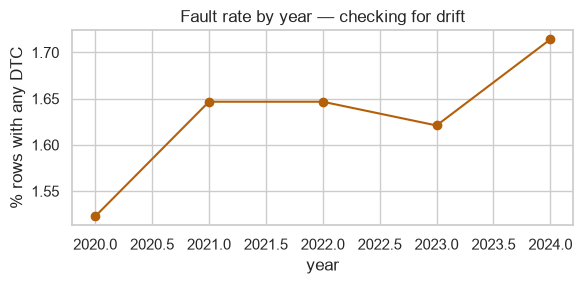

In [12]:
# Is fault rate stable over the 5-year span, or does it drift (which would make a
# chronological holdout have a different class balance than training)?
df["year"] = df["timestamp"].dt.year
year_rate = df.groupby("year")["is_fault"].mean().mul(100)
print("Fault rate by year (%):")
print(year_rate)

year_rate.plot(kind="line", marker="o", figsize=(6, 3), color="#B4600A")
plt.ylabel("% rows with any DTC")
plt.title("Fault rate by year — checking for drift")
plt.tight_layout()
plt.show()

### Findings

- **Fault episodes are almost entirely single, isolated hours.** Across all 2,722 fault episodes (a "episode" = one or more consecutive fault-labeled hours on one vehicle), **95.7% are exactly 1 hour long**; only ~4% run 2 hours and a handful run 3. This substantially reduces (though doesn't eliminate) the leakage concern above — faults here behave like isolated point events, not multi-hour persistent conditions.
- **Fault rate is roughly flat across the 5 years** (1.52%–1.71%, no strong trend). A chronological holdout (e.g. last year as test) should therefore have a similar class balance to the training years, not a skewed one.

### Decision: use a chronological split per vehicle for Week 2, not a random row split

Even though fault clustering turned out to be minor, a **random row-level split is still the wrong default for hourly time-series telemetry** — adjacent hours on the same vehicle share short-term sensor autocorrelation (e.g. a temperature ramp) independent of whether the label itself repeats. The defensible choice: **for each of the 4 vehicles, hold out the most recent ~20% of its timeline (chronologically) as the test set**, rather than a leave-one-vehicle-out split (impractical with only 4 vehicles spanning very different usage intensities — holding one out would swap a leakage problem for a distribution-shift problem) or a fully random split.

This is a documented methodology decision for Week 2, not yet implemented here — flagged so classifier training doesn't default to `train_test_split(..., random_state=42)` on the raw rows without thinking about it.

## 9. Resolving the `Warning`-class question

Carried over from the earlier discussion: `Warning` has only 205 rows (0.12%) — with the chronological ~80/20 split above, that's roughly **40 rows in test**, evenly enough spread across years that it's not concentrated in one split (per the flat year-over-year rate above), but still a small enough sample that any single-digit count of misclassifications swings its recall by several percentage points.

**Decision: keep `Fault_Label` as a 3-class target (Normal / Warning / Fault) for Week 2, but always report a binary Normal-vs-Any-Issue rollup alongside it, and treat `Warning`'s own precision/recall as directional, not a confident estimate.**

Why not just merge `Warning` into `Fault` and simplify to binary:
- The plan's own framing (Section 1: "is it safe to keep driving, or do I pull it in now") is inherently a 3-way triage decision, not binary — collapsing it would throw away the part of the story the project is built around.
- The `Warning` codes (`P0T`, `P0P`, `P0S`) are semantically distinct from the `Fault` codes (motor/battery) — merging would blur a real, meaningful distinction, not just a statistical nuisance.

Why the binary rollup matters as a companion metric:
- It gives a statistically reliable headline number (Fault vs. Warning combined is ~1.63% of rows, several times more test samples than Warning alone) to report confidently, while the 3-class breakdown still gets shown for the richer story — with the small-sample caveat stated explicitly rather than glossed over.

## 10. Save cleaned + labeled dataset

Persist the cleaned, concatenated, labeled dataset for Week 2's classifier training to consume directly (gitignored — see `data/.gitkeep` / `.gitignore`).

In [13]:
import os

os.makedirs("../data/processed", exist_ok=True)
out_path = "../data/processed/driving_pattern_diagnostics_cleaned.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} rows to {out_path}")

Saved 175,200 rows to ../data/processed/driving_pattern_diagnostics_cleaned.csv


## Summary

- **175,200 rows**, no duplicates, no nulls, all sensor ranges physically plausible.
- Derived `Fault_Label` (Normal / Warning / Fault) from the raw `DTC` column using an explicit, documented severity rule (motor/battery codes + multi-code rows → Fault; other single codes → Warning).
- Confirmed severe class imbalance — more extreme than the original plan's ~6% estimate: **Normal 98.37% / Fault 1.51% / Warning 0.12%**.
- **Realism check passed:** fault rate scales with usage intensity (0.99% rare_user → 2.57% heavy_user), an independent confirmation beyond the AUC 0.9999 signal test from dataset selection.
- **Time-series leakage checked, not assumed:** fault episodes are 95.7% single isolated hours (not multi-hour persistent runs), and fault rate is flat across the 5 years — but a **chronological per-vehicle split (last ~20% of each vehicle's timeline as test) is still the documented decision for Week 2**, not a random row split, since adjacent-hour sensor autocorrelation is a leakage risk independent of label clustering.
- **`Warning`-class decision resolved:** keep the 3-class target (matches the plan's 3-way triage framing and the codes' real semantic distinction), but always report a binary Normal-vs-Any-Issue rollup alongside it, and treat `Warning`'s own metrics (~40 test rows) as directional, not a confident estimate.
- Cleaned + labeled data saved to `data/processed/driving_pattern_diagnostics_cleaned.csv` for Week 2.

**Next:** Week 2 — train baseline (RF/XGBoost) then a small neural net classifier, using the chronological per-vehicle split and dual (3-class + binary rollup) evaluation decided above.